In [1]:
import os
import sys
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

pd.set_option("display.max_columns", None)

In [3]:
sys.path.append(os.path.abspath("../preprocessing"))

from preprocess_churn import load_and_prepare_data

data = load_and_prepare_data()

X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]

X_train.shape, X_test.shape

((4504, 27), (1126, 27))

In [4]:
selected_model = joblib.load("../../06_models/random_forest_churn_model.pkl")

selected_model

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [5]:
y_proba = selected_model.predict_proba(X_test)[:, 1]

y_proba[:10]

array([0.005, 0.015, 0.02 , 0.   , 0.11 , 0.025, 0.035, 0.   , 0.115,
       0.   ])

In [6]:
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70, 0.80]

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_proba >= threshold).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()
    
    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, y_pred_threshold),
        "precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "recall": recall_score(y_test, y_pred_threshold),
        "f1_score": f1_score(y_test, y_pred_threshold),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "true_negative": tn,
        "false_positive": fp,
        "false_negative": fn,
        "true_positive": tp,
        "customers_flagged_as_churn": int(y_pred_threshold.sum()),
        "flagged_share": y_pred_threshold.mean()
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,threshold,accuracy,precision,recall,f1_score,roc_auc,true_negative,false_positive,false_negative,true_positive,customers_flagged_as_churn,flagged_share
0,0.3,0.978686,0.891509,0.994737,0.940299,0.998251,913,23,1,189,212,0.188277
1,0.4,0.982238,0.942708,0.952632,0.947644,0.998251,925,11,9,181,192,0.170515
2,0.5,0.975133,0.965517,0.884211,0.923077,0.998251,930,6,22,168,174,0.154529
3,0.6,0.963588,0.993377,0.789474,0.879765,0.998251,935,1,40,150,151,0.134103
4,0.7,0.933393,1.000000,0.605263,0.754098,0.998251,936,0,75,115,115,0.102131
5,0.8,0.891652,1.000000,0.357895,0.527132,0.998251,936,0,122,68,68,0.060391


In [7]:
threshold_df.sort_values("f1_score", ascending=False)

,threshold,accuracy,precision,recall,f1_score,roc_auc,true_negative,false_positive,false_negative,true_positive,customers_flagged_as_churn,flagged_share
1,0.4,0.982238,0.942708,0.952632,0.947644,0.998251,925,11,9,181,192,0.170515
0,0.3,0.978686,0.891509,0.994737,0.940299,0.998251,913,23,1,189,212,0.188277
2,0.5,0.975133,0.965517,0.884211,0.923077,0.998251,930,6,22,168,174,0.154529
3,0.6,0.963588,0.993377,0.789474,0.879765,0.998251,935,1,40,150,151,0.134103
4,0.7,0.933393,1.000000,0.605263,0.754098,0.998251,936,0,75,115,115,0.102131
5,0.8,0.891652,1.000000,0.357895,0.527132,0.998251,936,0,122,68,68,0.060391


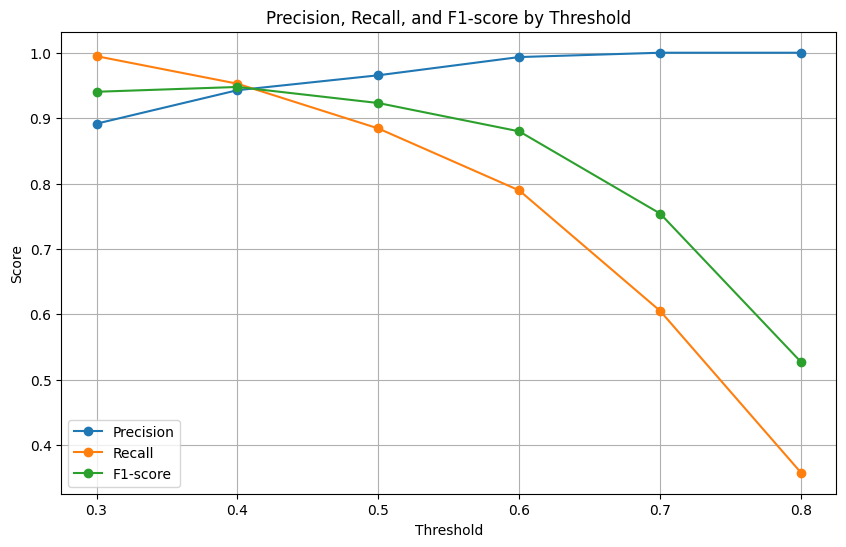

In [8]:
plt.figure(figsize=(10, 6))

plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1_score"], marker="o", label="F1-score")

plt.title("Precision, Recall, and F1-score by Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

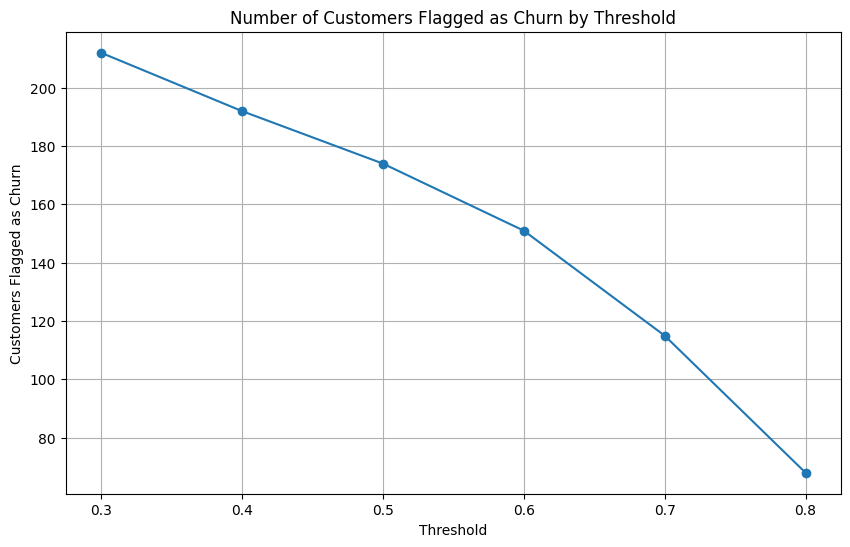

In [9]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["threshold"],
    threshold_df["customers_flagged_as_churn"],
    marker="o"
)

plt.title("Number of Customers Flagged as Churn by Threshold")
plt.xlabel("Threshold")
plt.ylabel("Customers Flagged as Churn")
plt.grid(True)
plt.show()

In [10]:
os.makedirs("../../05_outputs/model_results", exist_ok=True)
os.makedirs("../../05_outputs/figures", exist_ok=True)

threshold_df.to_csv(
    "../../05_outputs/model_results/threshold_analysis.csv",
    index=False
)

os.path.exists("../../05_outputs/model_results/threshold_analysis.csv")

True

## Threshold Analysis Summary and Conclusion

The selected Random Forest model outputs churn probabilities. By default, classification models often use a threshold of 0.50 to convert probabilities into class labels. However, in a churn prediction problem, the best threshold depends on the business objective.

This analysis compares multiple thresholds from 0.30 to 0.80 using precision, recall, F1-score, and the number of customers flagged as churn.

The results show a clear trade-off between recall and precision.

At a lower threshold such as 0.30, the model captures more churned customers and achieves very high recall. However, it also flags more customers as churn, which may increase retention campaign cost.

At higher thresholds such as 0.70 or 0.80, the model becomes more selective and achieves very high precision. However, recall drops significantly, meaning the company may miss many customers who are likely to churn.

Based on the comparison, threshold 0.40 provides the best balance between precision, recall, F1-score, and business actionability. It captures a high share of churned customers while still keeping the target group reasonably controlled.

Therefore, the baseline Random Forest remains the selected final model, while 0.40 can be considered as the recommended operating threshold for retention campaigns.

The final threshold decision should depend on the company's campaign budget and retention strategy:

- Use a lower threshold when the company wants to capture more potential churned customers.
- Use a higher threshold when the company wants to reduce campaign cost and focus only on the most certain churn-risk customers.

The threshold analysis output was saved to:

- `05_outputs/model_results/threshold_analysis.csv`

Figures were saved to:

- `05_outputs/figures/threshold_metric_comparison.png`
- `05_outputs/figures/threshold_customers_flagged.png`